# Lasso Baseline - Fractionation Dataset

Model Lasso com a baseline per predir D49 (yield %).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline

## 1. Carrega i neteja de dades

In [2]:
df = pd.read_csv('../../../data/fractionation_data.csv')
print(f'Original shape: {df.shape}')

# Drop non-numeric identifier
if 'A1' in df.columns:
    df = df.drop(columns=['A1'])

# Keep only numeric columns
df_numeric = df.select_dtypes(include=[np.number]).copy()
print(f'Numeric columns: {df_numeric.shape[1]}')

Original shape: (4616, 151)
Numeric columns: 127


/var/folders/jr/swhc70v52yqbt5xhyvfcyzn40000gp/T/ipykernel_7238/3119393901.py:1: DtypeWarning: Columns (63) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../../../data/fractionation_data.csv')


In [3]:
# Step 1: Remove columns with >35% missing values
missing_pct = df_numeric.isnull().sum() / len(df_numeric)
cols_keep = missing_pct[missing_pct <= 0.35].index.tolist()
df_clean = df_numeric[cols_keep].copy()
print(f'After removing >35% missing: {df_clean.shape}')

# Step 2: Remove low variance columns (< 0.10)
# Exclude target D49
feature_cols = [c for c in df_clean.columns if c != 'D49']
variances = df_clean[feature_cols].var()
low_var_cols = variances[variances < 0.10].index.tolist()
df_clean = df_clean.drop(columns=low_var_cols)
print(f'After removing low variance (<0.10): {df_clean.shape}')

# Step 3: Remove highly correlated features (>0.90)
feature_cols = [c for c in df_clean.columns if c != 'D49']
corr_matrix = df_clean[feature_cols].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper_tri.columns if any(upper_tri[col] > 0.90)]
df_clean = df_clean.drop(columns=high_corr_cols)
print(f'After removing high correlation (>0.90): {df_clean.shape}')

After removing >35% missing: (4616, 93)
After removing low variance (<0.10): (4616, 83)
After removing high correlation (>0.90): (4616, 66)


## 2. Preparacio de dades

In [4]:
# Separate features and target
if 'D49' not in df_clean.columns:
    raise ValueError('Target D49 not in dataset after cleaning')

# Drop rows with missing target
df_clean = df_clean.dropna(subset=['D49'])

X = df_clean.drop(columns=['D49'])
y = df_clean['D49']

# Fill remaining missing values with column mean
X = X.fillna(X.mean())

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'Target mean: {y.mean():.2f}, std: {y.std():.2f}')

Features shape: (4616, 65)
Target shape: (4616,)
Target mean: 44.22, std: 2.12


In [5]:
# StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
print('StandardScaler applied.')

StandardScaler applied.


## 3. Lasso Regression (alpha=0.01)

In [6]:
# Train Lasso with 5-fold CV
lasso = Lasso(alpha=0.01, max_iter=10000, random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation scores
mae_scores = -cross_val_score(lasso, X_scaled, y, cv=kf, scoring='neg_mean_absolute_error')
rmse_scores = np.sqrt(-cross_val_score(lasso, X_scaled, y, cv=kf, scoring='neg_mean_squared_error'))
r2_scores = cross_val_score(lasso, X_scaled, y, cv=kf, scoring='r2')

print('=== 5-Fold Cross-Validation Results ===')
print(f'MAE:  {mae_scores.mean():.4f} +/- {mae_scores.std():.4f}')
print(f'RMSE: {rmse_scores.mean():.4f} +/- {rmse_scores.std():.4f}')
print(f'R2:   {r2_scores.mean():.4f} +/- {r2_scores.std():.4f}')

=== 5-Fold Cross-Validation Results ===
MAE:  0.1999 +/- 0.0430
RMSE: 1.0689 +/- 0.5762
R2:   0.6863 +/- 0.2869


## 4. Feature Coefficients (Top 20)

In [7]:
# Fit on full data for coefficient analysis
lasso.fit(X_scaled, y)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso.coef_
})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)

# Non-zero coefficients
non_zero = coef_df[coef_df['Coefficient'] != 0]
print(f'Non-zero coefficients: {len(non_zero)} / {len(coef_df)}')
print(f'\nTop 20 features by |coefficient|:')
print(coef_df.head(20)[['Feature', 'Coefficient']].to_string(index=False))

Non-zero coefficients: 34 / 65

Top 20 features by |coefficient|:
Feature  Coefficient
    D61     1.313675
    D55    -1.239245
    D48     0.903008
    D59    -0.619761
    D15     0.335446
    D60     0.313849
    B27    -0.144008
    C29    -0.134518
    C40     0.085792
     D6    -0.069912
    D56     0.067787
    D36    -0.047266
    D47    -0.043734
    C33    -0.041219
    C39     0.039884
    D28     0.030824
    B24     0.030360
    D40     0.028524
    B16     0.026942
    D45    -0.024218


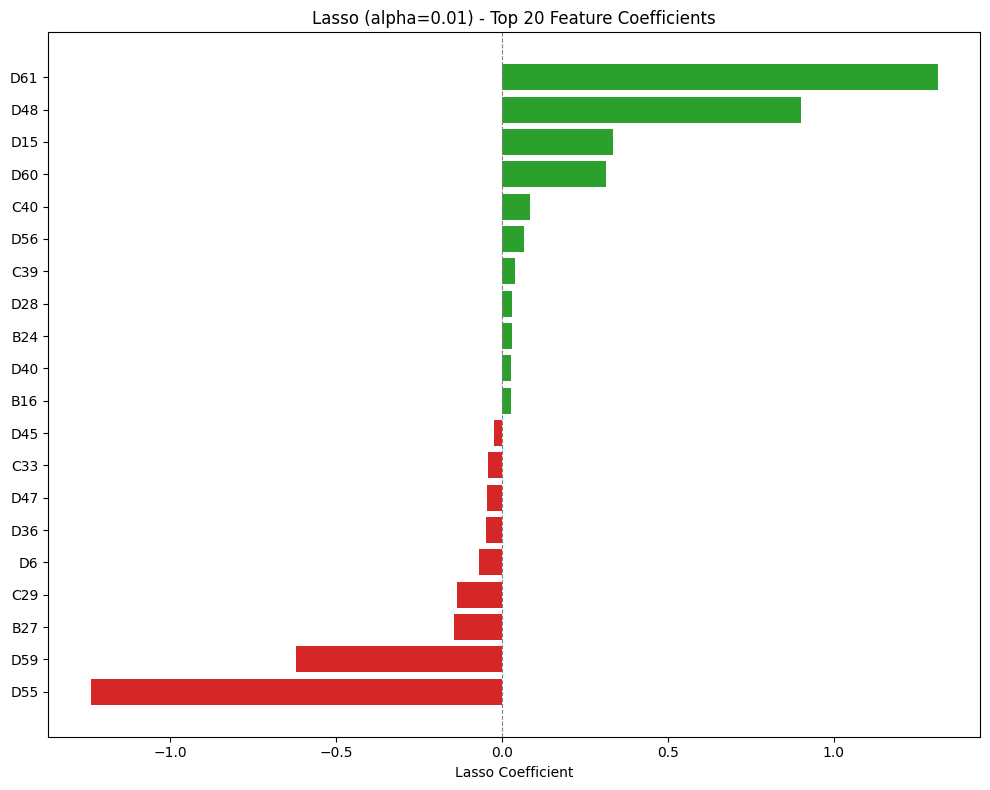

In [8]:
# Plot top 20 coefficients
top20 = coef_df.head(20).copy()
top20 = top20.sort_values('Coefficient')

colors = ['#d62728' if c < 0 else '#2ca02c' for c in top20['Coefficient']]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top20['Feature'], top20['Coefficient'], color=colors)
ax.set_xlabel('Lasso Coefficient')
ax.set_title('Lasso (alpha=0.01) - Top 20 Feature Coefficients')
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

## 5. Resum

In [9]:
print('='*60)
print('LASSO BASELINE SUMMARY')
print('='*60)
print(f'Dataset: {df_clean.shape[0]} samples, {X.shape[1]} features')
print(f'Model: Lasso (alpha=0.01)')
print(f'Preprocessing: StandardScaler')
print(f'CV: 5-fold')
print(f'---')
print(f'MAE:  {mae_scores.mean():.4f}')
print(f'RMSE: {rmse_scores.mean():.4f}')
print(f'R2:   {r2_scores.mean():.4f}')
print(f'---')
print(f'Non-zero features: {len(non_zero)}')
print(f'Top 5 features: {coef_df.head(5)["Feature"].tolist()}')
print('='*60)

LASSO BASELINE SUMMARY
Dataset: 4616 samples, 65 features
Model: Lasso (alpha=0.01)
Preprocessing: StandardScaler
CV: 5-fold
---
MAE:  0.1999
RMSE: 1.0689
R2:   0.6863
---
Non-zero features: 34
Top 5 features: ['D61', 'D55', 'D48', 'D59', 'D15']
